# TradeCoach

## 설계서 요약

### 01 LangGraph 노드 설계서 (v1.2)

| 레이어 | 노드 | 역할 |
|--------|------|------|
| 입력 | `memory_load_node` | DB에서 과거 약점/통계 로드 |
| 입력 | `input_router_node` | CSV / 이미지 / 혼합 입력 판별 |
| 분석 | `journal_analysis_node` | 통계 산출 (승률, 손익비, 드로다운) |
| 분석 | `weakness_detect_node` | 반복 실수 패턴 추출 |
| 분석 | `chart_analysis_node` | Claude Vision ICT 차트 분석 |
| 피드백 | `feedback_node` | 매수·매도 근거 피드백 생성 |
| 학습 | `lesson_gen_node` | 약점 기반 커리큘럼 생성 |
| 학습 | `quiz_node` | 개념 퀴즈 출제 |
| 학습 | `reinforce_node` | 오답 시 개념 보강 |
| 저장 | `memory_save_node` | 분석 결과 DB 저장 |

**라우팅 규칙**
- `input_router` → `journal_analysis` (journal only)
- `input_router` → `chart_analysis` (chart only)
- `input_router` → `journal_analysis` + `chart_analysis` (both)
- `quiz_node` pass → `memory_save` / fail & retry < 3 → `reinforce` / retry ≥ 3 → `memory_save`

### 04 API 명세서 (v1.2)

| 항목 | 값 |
|------|----|
| State 타입 | `TradeCoachState` (TypedDict) |
| DB | SQLite `tradecoach.db` (`db.py` 참조) |
| LLM 모델 | `claude-sonnet-4-6` (텍스트 + Vision 공용) |
| 노드 시그니처 | `(state: TradeCoachState) -> dict` |

---
**Step 2 구현 범위:** `TradeCoachState` · `memory_load_node` · `input_router_node` · 기본 그래프 연결

In [1]:
import os
from typing_extensions import TypedDict

from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END

from db import get_db, init_db

load_dotenv()

MODEL = "openai:gpt-4o"

init_db()
print("DB initialized")

DB initialized


/Users/kieokkim/Desktop/03_AIAgents/03_Langgraph/trade-coach/.venv/lib/python3.13/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## TradeCoachState

API 명세서 §2 기준 전체 필드. 노드는 변경할 키만 `dict`로 반환합니다.

In [2]:
class TradeCoachState(TypedDict, total=False):
    session_id:      str
    input_type:      str          # 'journal' | 'chart' | 'both'
    journal_data:    str          # CSV 원문
    chart_image:     str          # base64 인코딩 이미지
    stats:           dict         # 승률/손익비/드로다운 등
    weaknesses:      list         # 현재 세션 약점 태그
    past_weaknesses: list         # DB 로드 과거 약점
    chart_feedback:  str          # 차트 분석 결과 텍스트
    current_concept: str          # 현재 학습 중인 개념
    quiz_question:   str          # 퀴즈 문항
    quiz_answer:     str          # 사용자 답변
    quiz_result:     str          # 'pass' | 'fail' | ''
    retry_count:     int          # 퀴즈 재시도 횟수
    trade_count:     int          # 총 분석 트레이드 수
    improvement_log: list         # 세션별 실력 변화
    messages:        list         # 대화 히스토리
    setup_analysis:  dict         # 셋업별 승률 딕셔너리
    action_rule:     str          # 내일 실행할 규칙 1개
    concept_not_found: bool       # fallback 라우팅 플래그
    # D2: Bybit 연동 필드
    last_fetched_at: str          # ISO datetime, 마지막 Bybit 수집 시각
    has_new_data:    bool         # 새 체결 데이터 존재 여부
    raw_trades:      list         # Bybit API 원본 체결 목록


DEFAULT_STATE: TradeCoachState = {
    "session_id":      "default",
    "input_type":      "",
    "journal_data":    "",
    "chart_image":     "",
    "stats":           {},
    "weaknesses":      [],
    "past_weaknesses": [],
    "chart_feedback":  "",
    "current_concept": "",
    "quiz_question":   "",
    "quiz_answer":     "",
    "quiz_result":     "",
    "retry_count":     0,
    "trade_count":     0,
    "improvement_log": [],
    "messages":        [],
    "setup_analysis":  {},
    "action_rule":     "",
    "concept_not_found": False,
    # D2
    "last_fetched_at": "",
    "has_new_data":    False,
    "raw_trades":      [],
}

## memory_load_node

**역할:** 세션 시작 시 SQLite에서 과거 데이터 로드  
**입력:** `session_id`  
**출력:** `past_weaknesses`, `trade_count`, `improvement_log`  
**부수효과:** 없음 (읽기 전용). DB 없거나 오류 시 빈 값 반환.

In [3]:
def memory_load_node(state: TradeCoachState) -> dict:
    session_id = state.get("session_id", "default")
    past_weaknesses = []
    trade_count = 0
    improvement_log = []

    try:
        with get_db() as conn:
            rows = conn.execute(
                "SELECT weakness FROM weaknesses WHERE session_id = ? ORDER BY count DESC",
                (session_id,),
            ).fetchall()
            past_weaknesses = [r["weakness"] for r in rows]

            count_row = conn.execute(
                "SELECT COALESCE(SUM(trade_count), 0) FROM trade_history WHERE session_id = ?",
                (session_id,),
            ).fetchone()
            trade_count = int(count_row[0]) if count_row else 0

            history_rows = conn.execute(
                "SELECT date, win_rate, avg_rr FROM trade_history"
                " WHERE session_id = ? ORDER BY date DESC LIMIT 10",
                (session_id,),
            ).fetchall()
            improvement_log = [dict(r) for r in history_rows]
    except Exception:
        pass

    return {
        "past_weaknesses": past_weaknesses,
        "trade_count":     trade_count,
        "improvement_log": improvement_log,
    }

## input_router_node

**역할:** 입력 타입 판별 후 `input_type` 설정  

| journal_data | chart_image | input_type |
|:---:|:---:|:---:|
| ✓ | ✗ | `'journal'` |
| ✗ | ✓ | `'chart'` |
| ✓ | ✓ | `'both'` |
| ✗ | ✗ | `'journal'` (기본값) |

In [4]:
def input_router_node(state: TradeCoachState) -> dict:
    has_journal = bool(state.get("journal_data", "").strip())
    has_chart   = bool(state.get("chart_image",  "").strip())

    if has_journal and has_chart:
        input_type = "both"
    elif has_chart:
        input_type = "chart"
    else:
        input_type = "journal"

    return {"input_type": input_type}


def route_after_input(state: TradeCoachState) -> str:
    return state["input_type"]

## 그래프 연결

```
START → memory_load → input_router → (journal/chart/both) → END
```

Step 3+에서 `END` 스텁을 `journal_analysis_node`, `chart_analysis_node`로 교체 예정.

In [5]:
builder = StateGraph(TradeCoachState)

builder.add_node("memory_load",  memory_load_node)
builder.add_node("input_router", input_router_node)

builder.add_edge(START, "memory_load")
builder.add_edge("memory_load", "input_router")
builder.add_conditional_edges(
    "input_router",
    route_after_input,
    {
        "journal": END,
        "chart":   END,
        "both":    END,
    },
)

graph = builder.compile()
print("Graph compiled")

Graph compiled


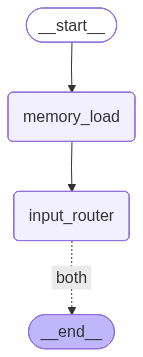

In [6]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## 동작 테스트

In [7]:
test_cases = [
    {"label": "journal only", "journal_data": "date,result\n2026-05-01,win", "chart_image": ""},
    {"label": "chart only",   "journal_data": "",                            "chart_image": "base64data=="},
    {"label": "both inputs",  "journal_data": "date,result\n2026-05-01,win", "chart_image": "base64data=="},
    {"label": "empty input",  "journal_data": "",                            "chart_image": ""},
]

for tc in test_cases:
    state = {**DEFAULT_STATE, "session_id": "test_user",
             "journal_data": tc["journal_data"], "chart_image": tc["chart_image"]}
    result = graph.invoke(state)
    print(f"[{tc['label']:13s}] input_type={result['input_type']!r:10s}"
          f" past_weaknesses={result['past_weaknesses']}"
          f" trade_count={result['trade_count']}")

[journal only ] input_type='journal'  past_weaknesses=[] trade_count=0
[chart only   ] input_type='chart'    past_weaknesses=[] trade_count=0
[both inputs  ] input_type='both'     past_weaknesses=[] trade_count=0
[empty input  ] input_type='journal'  past_weaknesses=[] trade_count=0


---
# Step 3: journal_analysis_node · weakness_detect_node

| 노드 | 역할 | LLM |
|------|------|-----|
| `journal_analysis_node` | CSV → stats (win_rate / avg_rr / max_drawdown / best·worst_setup) | OpenAI `gpt-4o-mini` |
| `weakness_detect_node` | stats + past_weaknesses → weakness 태그 리스트 | 없음 (임계값 규칙 기반) |

**임계값 규칙 (노드 설계서 §3.3)**

| 지표 | 임계값 | 약점 태그 |
|------|--------|----------|
| win_rate | < 0.4 | `승률_낮음` |
| avg_rr | < 1.5 | `손익비_부족` |
| max_drawdown | ≥ 3 | `연속손실_패턴` |
| worst_setup | 존재 시 | `{setup명}_개선필요` |

**그래프 변경:** `input_router → journal_analysis → weakness_detect → END`  
(`chart` 경로는 Step 4에서 `chart_analysis_node` 연결 예정)

In [8]:
from nodes.analysis_nodes import journal_analysis_node, weakness_detect_node

### 그래프 재구성

```
START
  └─ memory_load
       └─ input_router
            ├─ journal ──┐
            ├─ both ─────┤
            │            ▼
            │    journal_analysis
            │            └─ weakness_detect → END
            └─ chart ──→ END  (Step 4 예정)
```

In [9]:
builder = StateGraph(TradeCoachState)

builder.add_node("memory_load",      memory_load_node)
builder.add_node("input_router",     input_router_node)
builder.add_node("journal_analysis", journal_analysis_node)
builder.add_node("weakness_detect",  weakness_detect_node)

builder.add_edge(START, "memory_load")
builder.add_edge("memory_load", "input_router")
builder.add_conditional_edges(
    "input_router",
    route_after_input,
    {
        "journal": "journal_analysis",
        "both":    "journal_analysis",  # chart_analysis_node - Step 4
        "chart":   END,                 # chart_analysis_node - Step 4
    },
)
builder.add_edge("journal_analysis", "weakness_detect")
builder.add_edge("weakness_detect",  END)

graph = builder.compile()
print("Graph compiled")

Graph compiled


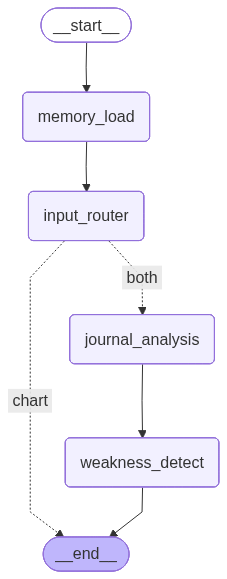

In [10]:
Image(graph.get_graph().draw_mermaid_png())

### 동작 테스트

> `OPENAI_API_KEY` 필요. `journal_analysis_node`가 OpenAI를 호출합니다.

In [11]:
test_journal = """date,setup,result,rr
2026-05-01,FVG,win,2.1
2026-05-02,FVG,loss,-1.0
2026-05-03,OrderBlock,win,1.8
2026-05-04,OrderBlock,loss,-1.0
2026-05-05,FVG,loss,-1.0
2026-05-06,FVG,loss,-1.0"""

result = graph.invoke({
    **DEFAULT_STATE,
    "session_id":   "test_user",
    "journal_data": test_journal,
})

print("stats:      ", result["stats"])
print("weaknesses: ", result["weaknesses"])
print("input_type: ", result["input_type"])

stats:       {'win_rate': 0.3333333333333333, 'avg_rr': 1.6333333333333333, 'max_drawdown': 4, 'best_setup': 'FVG', 'worst_setup': 'OrderBlock', 'trade_count': 6, 'setup_analysis': {'FVG': 0.25, 'OrderBlock': 0.5}, 'action_rule': 'FVG 셋업은 더 이상 손실이 발생하지 않도록 주의할 것'}
weaknesses:  ['승률_낮음', '연속손실_패턴', 'OrderBlock_개선필요']
input_type:  journal


---
# Step 4: chart_analysis_node · feedback_node

| 노드 | 역할 | LLM |
|------|------|-----|
| `chart_analysis_node` | base64 이미지 → OpenAI Vision → ICT 근거 분석 | `gpt-4o` (Vision) |
| `feedback_node` | 분석 결과 구조화 → weakness 병합 | `gpt-4o-mini` |

**그래프 변경 (Step 3 → Step 4)**

```
journal → journal_analysis → weakness_detect → END
chart   → chart_analysis   → feedback        → END
both    → journal_analysis → weakness_detect → chart_analysis → feedback → END
```

In [12]:
from nodes.chart_nodes import chart_analysis_node, feedback_node

In [13]:
from nodes.fallback_node import fallback_classify_node


def route_after_weakness(state: TradeCoachState) -> str:
    if state.get("concept_not_found"):
        return "fallback_classify"
    return "chart_analysis" if state.get("input_type") == "both" else END


def route_after_fallback(state: TradeCoachState) -> str:
    return "chart_analysis" if state.get("input_type") == "both" else END


builder = StateGraph(TradeCoachState)

builder.add_node("memory_load",       memory_load_node)
builder.add_node("input_router",      input_router_node)
builder.add_node("journal_analysis",  journal_analysis_node)
builder.add_node("weakness_detect",   weakness_detect_node)
builder.add_node("fallback_classify", fallback_classify_node)
builder.add_node("chart_analysis",    chart_analysis_node)
builder.add_node("feedback",          feedback_node)

builder.add_edge(START, "memory_load")
builder.add_edge("memory_load", "input_router")
builder.add_conditional_edges(
    "input_router",
    route_after_input,
    {
        "journal": "journal_analysis",
        "both":    "journal_analysis",
        "chart":   "chart_analysis",
    },
)
builder.add_edge("journal_analysis", "weakness_detect")
builder.add_conditional_edges(
    "weakness_detect",
    route_after_weakness,
    {
        "fallback_classify": "fallback_classify",
        "chart_analysis":    "chart_analysis",
        END:                 END,
    },
)
builder.add_conditional_edges(
    "fallback_classify",
    route_after_fallback,
    {
        "chart_analysis": "chart_analysis",
        END:              END,
    },
)
builder.add_edge("chart_analysis", "feedback")
builder.add_edge("feedback", END)

graph = builder.compile()
print("Graph compiled")


Graph compiled


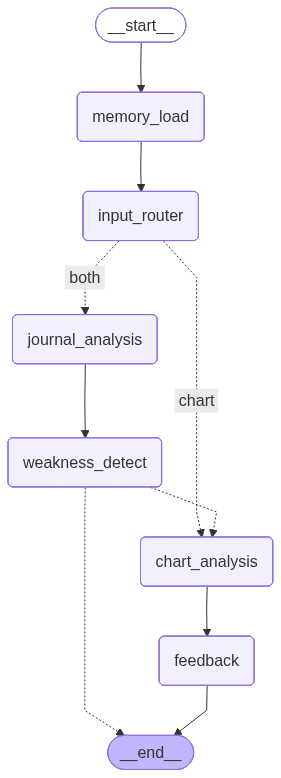

In [14]:
Image(graph.get_graph().draw_mermaid_png())

### 동작 테스트

**journal 경로** — journal_analysis + weakness_detect 실행 (OpenAI `gpt-4o-mini` 호출)  
**chart 경로** — chart_analysis + feedback 실행 (OpenAI Vision `gpt-4o` 호출, 실제 base64 이미지 필요)  
**both 경로** — 전체 파이프라인 순차 실행

In [15]:
# journal 경로: Step 3과 동일하게 동작 검증
result_j = graph.invoke({
    **DEFAULT_STATE,
    "session_id":   "test_user",
    "journal_data": test_journal,
})
print("[journal] input_type :", result_j["input_type"])
print("[journal] stats      :", result_j["stats"])
print("[journal] weaknesses :", result_j["weaknesses"])
print("[journal] chart_feedback:", repr(result_j.get("chart_feedback", "")))

[journal] input_type : journal
[journal] stats      : {'win_rate': 0.3333333333333333, 'avg_rr': 1.6333333333333333, 'max_drawdown': 4, 'best_setup': 'FVG', 'worst_setup': 'OrderBlock', 'trade_count': 6, 'setup_analysis': {'FVG': 0.25, 'OrderBlock': 0.5}, 'action_rule': 'FVG 셋업은 BOS 확인 후에만 진입할 것'}
[journal] weaknesses : ['승률_낮음', '연속손실_패턴', 'OrderBlock_개선필요']
[journal] chart_feedback: ''


In [16]:
# chart 경로: 실제 이미지 base64로 교체하면 Vision 분석 실행
# import base64, pathlib
# chart_b64 = base64.b64encode(pathlib.Path("chart.png").read_bytes()).decode()

# 아래는 빈 이미지로 라우팅 경로만 확인 (chart_feedback = "")
result_c = graph.invoke({
    **DEFAULT_STATE,
    "session_id":  "test_user",
    "chart_image": "",          # ← 실제 base64로 교체
})
print("[chart] input_type   :", result_c["input_type"])
print("[chart] chart_feedback:", repr(result_c.get("chart_feedback", ""))[:80])
print("[chart] weaknesses   :", result_c.get("weaknesses", []))

[chart] input_type   : journal
[chart] chart_feedback: ''
[chart] weaknesses   : ['승률_낮음', '손익비_부족']


---
# Step 5: search_ict_concept 테스트

`tools/concept_tool.py`의 `search_ict_concept` 도구를 직접 호출해
각 weakness 태그별 조회 결과 및 fallback 동작을 확인합니다.

In [17]:
from tools.concept_tool import search_ict_concept

# 정의된 weakness 태그 전체 조회
tags = [
    "FVG",
    "OrderBlock",
    "BreakerBlock",
    "유동성스윕",
    "BOS",
    "CHoCH",
    "OTE",
    "프리미엄_디스카운트",
    "손익비_부족",
    "연속손실_패턴",
    "승률_낮음",
]

for tag in tags:
    result = search_ict_concept.invoke({"weakness_tag": tag})
    print(result)
    print("-" * 60)

【FVG】
정의: 캔들 3개로 만들어지는 가격 공백 구간으로, 미충족 주문이 모여 있어 가격이 재방문하는 경향이 있는 영역

핵심 포인트:
  • 1번 캔들 고점과 3번 캔들 저점 사이에 겹치지 않는 공간이 FVG
  • 불리시 FVG는 지지, 베어리시 FVG는 저항으로 작용
  • 50% 미드포인트가 OTE 진입 기준점으로 활용됨

개선 방법: 진입 전 HTF(상위 시간대) 구조 방향과 FVG 방향이 일치하는지 먼저 확인 후 진입
------------------------------------------------------------
【OrderBlock】
정의: 기관이 대량 주문을 실행한 마지막 반대 방향 캔들로, 가격이 재방문 시 강한 반응이 나타나는 구간

핵심 포인트:
  • 불리시 OB: 강한 상승 전 마지막 베어리시 캔들
  • 베어리시 OB: 강한 하락 전 마지막 불리시 캔들
  • BOS 이후 형성된 OB가 유효성이 높음

개선 방법: OB 형성 캔들의 오픈~클로즈 범위를 정확히 표시하고 50% 이상 진입 시에만 유효 OB로 인정
------------------------------------------------------------
【BreakerBlock】
정의: 원래 OB 기능을 상실하고 반대 방향의 저항/지지로 전환된 구간

핵심 포인트:
  • OB가 돌파(Mitigated)된 후 브레이커로 전환
  • 불리시 BB: 실패한 베어리시 OB → 지지로 전환
  • 브레이커는 OB보다 신뢰도가 높은 레벨로 간주

개선 방법: OB가 완전히 돌파된 경우 브레이커로 재분류하고 반대 방향 반응을 기대하도록 마킹 업데이트
------------------------------------------------------------
【유동성스윕】
정의: 기관이 리테일 트레이더의 손절 주문을 흡수하기 위해 주요 고점/저점을 일시적으로 돌파하는 가격 움직임

핵심 포인트:
  • BSL(Buy-Side Liquidity): 스윙 고점 위 매수 스

### 부분 매칭 및 fallback 테스트

In [18]:
# 부분 매칭: 'fvg'(소문자), 'orderblock'(소문자)
for tag in ["fvg", "orderblock", "bos", "choch"]:
    result = search_ict_concept.invoke({"weakness_tag": tag})
    first_line = result.split('\n')[0]
    print(f"[{tag:15s}] → {first_line}")

print()

# weakness_detect_node가 생성하는 '_개선필요' 형태 태그 조회
# (예: 'OrderBlock_개선필요' → 'OrderBlock' 부분 매칭)
for tag in ["OrderBlock_개선필요", "FVG_개선필요"]:
    result = search_ict_concept.invoke({"weakness_tag": tag})
    first_line = result.split('\n')[0]
    print(f"[{tag:25s}] → {first_line}")

print()

# fallback: 매칭되지 않는 태그
for tag in ["UnknownSetup", "랜덤태그", ""]:
    result = search_ict_concept.invoke({"weakness_tag": tag})
    print(f"[{tag:20s}] → {result}")

[fvg            ] → 【FVG】
[orderblock     ] → 【OrderBlock】
[bos            ] → 【BOS】
[choch          ] → 【CHoCH】

[OrderBlock_개선필요          ] → 【OrderBlock】
[FVG_개선필요                 ] → 【FVG】

[UnknownSetup        ] → 해당 개념을 찾을 수 없습니다: 'UnknownSetup'
[랜덤태그                ] → 해당 개념을 찾을 수 없습니다: '랜덤태그'
[                    ] → 【FVG】
정의: 캔들 3개로 만들어지는 가격 공백 구간으로, 미충족 주문이 모여 있어 가격이 재방문하는 경향이 있는 영역

핵심 포인트:
  • 1번 캔들 고점과 3번 캔들 저점 사이에 겹치지 않는 공간이 FVG
  • 불리시 FVG는 지지, 베어리시 FVG는 저항으로 작용
  • 50% 미드포인트가 OTE 진입 기준점으로 활용됨

개선 방법: 진입 전 HTF(상위 시간대) 구조 방향과 FVG 방향이 일치하는지 먼저 확인 후 진입


### weakness_detect_node 통합 테스트

`weakness_detect_node`가 1순위 약점 개념을 자동으로 `messages`에 추가하는지 확인합니다.

In [19]:
# journal 경로 실행 → weakness_detect_node 내부에서 search_ict_concept 자동 호출
result = graph.invoke({
    **DEFAULT_STATE,
    "session_id":   "test_user",
    "journal_data": test_journal,
})

print("weaknesses:", result["weaknesses"])
print()
print("messages count:", len(result["messages"]))
if result["messages"]:
    print("\n--- 1순위 약점 개념 설명 ---")
    print(result["messages"][-1].content)

weaknesses: ['승률_낮음', '연속손실_패턴', 'OrderBlock_개선필요']

messages count: 1

--- 1순위 약점 개념 설명 ---
【승률_낮음】
정의: 전체 매매 중 수익 거래 비율이 40% 미만으로 진입 기준 또는 시장 이해 부족을 나타냄

핵심 포인트:
  • 승률 40% 미만이면 RR 2.0 이상 없이는 장기 수익 불가능
  • 진입 기준의 명확성과 일관성 부재가 주요 원인
  • 셋업 조건(confluences) 2개 이상 충족 시에만 진입하는 필터 필요

개선 방법: 매매 전 체크리스트(HTF 방향, OB/FVG 확인, 유동성 스윕 확인) 3개 이상 충족 시에만 진입 허용


In [20]:
# 셀 1 - 샘플 저널 데이터
test_journal = """date,result,rr,setup
2026-05-01,loss,0.8,FVG
2026-05-02,loss,0.9,FVG
2026-05-03,loss,1.0,OB
2026-05-04,win,1.2,OB
2026-05-05,loss,0.7,FVG
2026-05-06,win,2.1,유동성스윕
2026-05-07,loss,0.8,OB
2026-05-08,win,1.3,FVG
2026-05-09,loss,0.9,OB
2026-05-10,loss,1.1,FVG"""

In [21]:
# 셀 2 - 한 사이클 실행
result = graph.invoke({
    **DEFAULT_STATE,
    "session_id":   "my_session",
    "journal_data": test_journal,
})

In [22]:
# 셀 3 - 결과 출력
print("=" * 50)
print("📊 통계 분석")
print("=" * 50)
for k, v in result["stats"].items():
    print(f"  {k}: {v}")

print()
print("=" * 50)
print("⚠️  감지된 약점")
print("=" * 50)
for w in result["weaknesses"]:
    print(f"  • {w}")

print()
print("=" * 50)
print("📚 1순위 약점 개념 설명")
print("=" * 50)
if result["messages"]:
    print(result["messages"][-1].content)
else:
    print("약점 없음")

📊 통계 분석
  win_rate: 0.4
  avg_rr: 1.1
  max_drawdown: 3
  best_setup: 유동성스윕
  worst_setup: FVG
  trade_count: 10
  setup_analysis: {'FVG': 0.33, 'OB': 0.25, '유동성스윕': 1.0}
  action_rule: FVG 셋업은 더 이상 진입하지 말 것

⚠️  감지된 약점
  • 손익비_부족
  • 연속손실_패턴
  • FVG_개선필요

📚 1순위 약점 개념 설명
【손익비_부족】
정의: 평균 손익비(RR)가 1.5 미만으로 손실 대비 수익이 충분하지 않은 매매 패턴

핵심 포인트:
  • RR 1.5 이상이어야 승률 40%에서도 수익 가능
  • 타겟을 가까운 레벨에서 일찍 청산하는 습관이 원인
  • 손절 폭 대비 최소 1.5배 이상의 타겟 설정 필요

개선 방법: 진입 전 손절-타겟 레벨을 명확히 설정하고 RR 1.5 미만이면 진입 자체를 포기하는 규칙 수립


In [23]:
# 셀 4 - setup_analysis & action_rule 출력
print("=" * 50)
print("📈 셋업별 승률")
print("=" * 50)
setup_analysis = result.get("setup_analysis", {})
if setup_analysis:
    for setup, wr in sorted(setup_analysis.items(), key=lambda x: -x[1]):
        bar = "█" * int(wr * 20)
        print(f"  {setup:<15s} {wr:.0%}  {bar}")
else:
    print("  (셋업 데이터 없음)")

print()
print("=" * 50)
print("★ 내일의 규칙")
print("=" * 50)
action_rule = result.get("action_rule", "")
print(f"  {action_rule}" if action_rule else "  (규칙 없음)")

📈 셋업별 승률
  유동성스윕           100%  ████████████████████
  FVG             33%  ██████
  OB              25%  █████

★ 내일의 규칙
  FVG 셋업은 더 이상 진입하지 말 것


---
# D1 안정화 테스트

## 테스트 1: 비정형 컬럼명 CSV → preprocess → stats 정상 출력

`preprocess_node`가 컬럼명을 소문자/공백 제거로 정규화하여
`journal_analysis_node`가 정상 동작하는지 검증합니다.

In [ ]:
# D1 테스트 1 - 비정형 컬럼명 CSV → preprocess → stats 정상 출력
import logging
logging.basicConfig(level=logging.INFO, format='%(name)s | %(levelname)s | %(message)s')

from nodes.preprocess_nodes import preprocess_node

# 비정형 컬럼명: 대문자, 공백 포함
malformed_csv = """Date , Result , RR , Setup
2026-04-01,win,2.1,FVG
2026-04-02,Loss,0.8,OB
2026-04-03,WIN,1.5,FVG
2026-04-04,loss,0.9,OB
2026-04-05,win,2.3,유동성스윕
2026-04-06,loss,0.7,FVG
2026-04-07,win,1.8,OB
"""

state = {**DEFAULT_STATE, 'session_id': 'd1_test1', 'journal_data': malformed_csv}
preprocessed = preprocess_node(state)

print('[preprocess] 정규화된 journal_data:')
print(preprocessed.get('journal_data', '(없음)'))

# preprocess 결과를 state에 합쳐서 그래프 실행
merged_state = {**state, **preprocessed}
result_t1 = graph.invoke(merged_state)

print('\n[stats]')
for k, v in result_t1.get('stats', {}).items():
    print(f'  {k}: {v}')

print('\n[weaknesses]', result_t1.get('weaknesses', []))
print('[action_rule]', result_t1.get('action_rule', ''))

assert result_t1.get('stats') and 'error' not in result_t1['stats'], \
    'D1 테스트1 실패: stats에 error가 포함됨'
print('\nD1 테스트 1 PASS')

## 테스트 2: sample_trades.json 로드 → preprocess → stats 정상 출력

Bybit API 응답 형식의 샘플 데이터를 `preprocess_node`로 정규화하고
`journal_analysis_node`가 정상 동작하는지 검증합니다.

In [ ]:
# D1 테스트 2 - sample_trades.json → preprocess → stats 정상 출력
import json as _json
from pathlib import Path

sample_path = Path('data/sample_trades.json')
sample_data = _json.loads(sample_path.read_text(encoding='utf-8'))
raw_trades = sample_data['result']['list']

print(f'로드된 체결 건수: {len(raw_trades)}건')

state_t2 = {**DEFAULT_STATE, 'session_id': 'd1_test2', 'raw_trades': raw_trades}
preprocessed_t2 = preprocess_node(state_t2)

print('\n[preprocess] 정규화된 journal_data (Bybit):')
print(preprocessed_t2.get('journal_data', '(없음)'))

merged_state_t2 = {**state_t2, **preprocessed_t2}
# raw_trades는 그래프 실행 시 preprocess_node가 없으므로 journal_data만 사용
merged_state_t2.pop('raw_trades', None)

result_t2 = graph.invoke(merged_state_t2)

print('\n[stats]')
for k, v in result_t2.get('stats', {}).items():
    print(f'  {k}: {v}')

print('\n[weaknesses]', result_t2.get('weaknesses', []))
print('[setup_analysis]', result_t2.get('setup_analysis', {}))
print('[action_rule]', result_t2.get('action_rule', ''))

assert result_t2.get('stats') and 'error' not in result_t2['stats'], \
    'D1 테스트2 실패: stats에 error가 포함됨'
print('\nD1 테스트 2 PASS')

---
# D2: Bybit 연동

```
START → memory_load → new_data_check
          has_new_data=True  → bybit_fetch → preprocess → input_router → journal_analysis → weakness_detect → ...
          has_new_data=False → END
```


In [ ]:
from nodes.fetch_nodes import new_data_check_node, bybit_fetch_node
from nodes.preprocess_nodes import preprocess_node


def route_after_check(state: TradeCoachState) -> str:
    return 'bybit_fetch' if state.get('has_new_data') else END


builder = StateGraph(TradeCoachState)

builder.add_node('memory_load',       memory_load_node)
builder.add_node('new_data_check',    new_data_check_node)
builder.add_node('bybit_fetch',       bybit_fetch_node)
builder.add_node('preprocess',        preprocess_node)
builder.add_node('input_router',      input_router_node)
builder.add_node('journal_analysis',  journal_analysis_node)
builder.add_node('weakness_detect',   weakness_detect_node)
builder.add_node('fallback_classify', fallback_classify_node)
builder.add_node('chart_analysis',    chart_analysis_node)
builder.add_node('feedback',          feedback_node)

builder.add_edge(START, 'memory_load')
builder.add_edge('memory_load', 'new_data_check')
builder.add_conditional_edges(
    'new_data_check',
    route_after_check,
    {'bybit_fetch': 'bybit_fetch', END: END},
)
builder.add_edge('bybit_fetch', 'preprocess')
builder.add_edge('preprocess', 'input_router')
builder.add_conditional_edges(
    'input_router',
    route_after_input,
    {'journal': 'journal_analysis', 'both': 'journal_analysis', 'chart': 'chart_analysis'},
)
builder.add_edge('journal_analysis', 'weakness_detect')
builder.add_conditional_edges(
    'weakness_detect',
    route_after_weakness,
    {'fallback_classify': 'fallback_classify', 'chart_analysis': 'chart_analysis', END: END},
)
builder.add_conditional_edges(
    'fallback_classify',
    route_after_fallback,
    {'chart_analysis': 'chart_analysis', END: END},
)
builder.add_edge('chart_analysis', 'feedback')
builder.add_edge('feedback', END)

graph = builder.compile()
print('D2 Graph compiled')


In [ ]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())


## D2 테스트

### 케이스 1: 첫 실행 (last_fetched_at 비어있음) → has_new_data=True → 전체 파이프라인
### 케이스 2: 이미 수집한 이후 → has_new_data=False → END 분기


In [ ]:
# 케이스 1: 첫 실행 (last_fetched_at 비어있음)
state = {**DEFAULT_STATE, 'session_id': 'test_user', 'last_fetched_at': ''}
result = graph.invoke(state)

print('has_new_data:', result.get('has_new_data'))
print('raw_trades 수:', len(result.get('raw_trades', [])))
print('journal_data 미리보기:')
print(result.get('journal_data', '')[:200])
print('last_fetched_at:', result.get('last_fetched_at', ''))

print()
print('[stats]')
for k, v in result.get('stats', {}).items():
    print(f'  {k}: {v}')

assert result.get('has_new_data') is True, 'D2 케이스1: has_new_data가 True여야 함'
assert len(result.get('raw_trades', [])) > 0, 'D2 케이스1: raw_trades가 비어있음'
print('\nD2 케이스 1 PASS')


In [ ]:
# 케이스 2: 이미 수집한 이후 (최신 시각 이후로 설정)
state = {**DEFAULT_STATE, 'session_id': 'test_user', 'last_fetched_at': '2099-01-01T00:00:00+00:00'}
result = graph.invoke(state)

print('has_new_data:', result.get('has_new_data'))  # False → END 분기 확인
print('raw_trades 수:', len(result.get('raw_trades', [])))
print('journal_data:', repr(result.get('journal_data', '')[:50]))

assert result.get('has_new_data') is False, 'D2 케이스2: has_new_data가 False여야 함'
assert result.get('raw_trades', []) == [], 'D2 케이스2: END 분기이므로 raw_trades는 비어있어야 함'
print('\nD2 케이스 2 PASS (END 분기 확인)')
